# Classificação do desempenho no ENEM — cinco famílias de algoritmos

Cada classificador é executado separadamente com `cross_validate`. O alvo possui três classes: Baixa, Média e Alta. Entre as cinco variantes de Naive Bayes testadas, o MultinomialNB foi selecionado pelo maior F1 macro.

O `Pipeline` garante que a imputação e, quando necessária, a padronização sejam ajustadas novamente usando apenas o treino de cada fold. O `cross_validate` cria e treina uma cópia independente desse pipeline em cada divisão.

In [1]:
# importação das bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

In [ ]:
# Função para imprimir e guardar os resultados de cada modelo
def imprimir_resultados(nome_modelo, resultado_cv):
    tabela = pd.DataFrame({
        "Acurácia": resultado_cv["test_accuracy"],
        "Precisão macro": resultado_cv["test_precision_macro"],
        "Recall macro": resultado_cv["test_recall_macro"],
        "F1 macro": resultado_cv["test_f1_macro"],
    })
    tabela.index = [f"Fold {i + 1}" for i in range(len(tabela))]
    tabela.loc["Média"] = tabela.mean()
    tabela.loc["Desvio padrão"] = tabela.iloc[:-1].std(ddof=1)

    print(f"RESULTADOS DA VALIDAÇÃO CRUZADA — {nome_modelo}")
    display(tabela.style.format("{:.4f}"))
    return tabela

## Base, atributos e validação

O CSV já possui os atributos categóricos transformados em números. `media_geral` e `classe` são retiradas de `X`, porque determinam diretamente o resultado que queremos prever.

A base ainda possui valores ausentes. Por isso, `SimpleImputer` será incluído no pipeline de cada modelo. Ele calculará uma mediana diferente em cada fold, sempre a partir da parte usada para treinamento.

In [3]:
df_acre = pd.read_csv("base_dados/MICRODADOS_ENEM_2023_AC_PARA_CLASSIFICACAO.csv")
df_acre.head()

,TP_FAIXA_ETARIA_1,TP_FAIXA_ETARIA_2,TP_FAIXA_ETARIA_3,TP_FAIXA_ETARIA_4,TP_FAIXA_ETARIA_5,TP_FAIXA_ETARIA_6,TP_FAIXA_ETARIA_7,TP_FAIXA_ETARIA_8,TP_FAIXA_ETARIA_9,TP_FAIXA_ETARIA_10,...,Q022_E,Q023_B,Q024_A,Q024_B,Q024_C,Q024_D,Q024_E,Q025_B,media_geral,classe
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,391.10,Baixa
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,393.16,Baixa
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,648.84,Media
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,435.68,Baixa
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,548.14,Media


In [4]:

X = df_acre.drop(columns=["media_geral", "classe"]).copy()

y = df_acre["classe"]

assert y.notna().all(), "Existem classes ausentes ou não reconhecidas."
assert y.isin(["Baixa", "Media", "Alta"]).all()
assert all(pd.api.types.is_numeric_dtype(tipo) for tipo in X.dtypes)
assert not np.isinf(X.to_numpy()).any()

cv_est = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42,
)

metricas = {
    "accuracy": "accuracy",
    "precision_macro": make_scorer(
        precision_score, average="macro", zero_division=0
    ),
    "recall_macro": make_scorer(
        recall_score, average="macro", zero_division=0
    ),
    "f1_macro": make_scorer(
        f1_score, average="macro", zero_division=0
    ),
}

resultados_modelos = {}

display(
    y.value_counts().to_frame("Quantidade")
)
print(f"Acurácia de referência: {y.value_counts(normalize=True).max():.1%}")

,Quantidade
classe,
Media,7909
Baixa,6895
Alta,295


Acurácia de referência: 52.4%


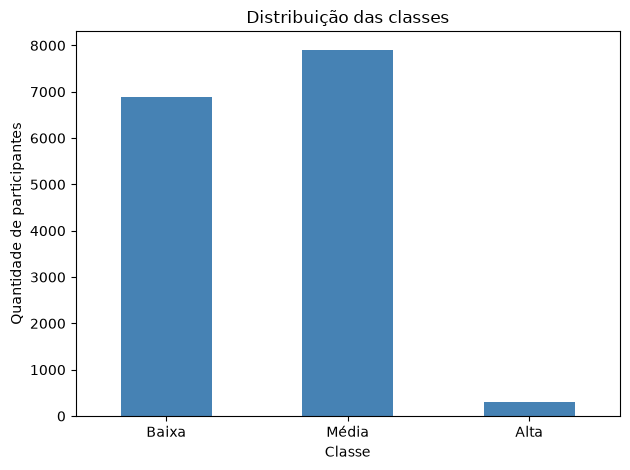

,Quantidade
Classe,
Baixa,6895
Média,7909
Alta,295


In [5]:
# Distribuição das classes

distribuicao_classes = (
    pd.Series(y, name="Classe")
    .astype(str)
    .str.strip()
    .replace({"Media": "Média"})
    .value_counts()
    .reindex(["Baixa", "Média", "Alta"], fill_value=0)
)

ax = distribuicao_classes.plot.bar(color="steelblue")
ax.set_title("Distribuição das classes")
ax.set_xlabel("Classe")
ax.set_ylabel("Quantidade de participantes")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

display(distribuicao_classes.rename("Quantidade").to_frame())

## 1. Random Forest

A árvore e a Random Forest não precisam de padronização, mas não aceitam os valores ausentes desta base. Por isso, seu pipeline contém apenas a imputação e o classificador.

In [6]:
modelo_random_forest = Pipeline([
    ("imputacao", SimpleImputer(strategy="median", keep_empty_features=True)),
    ("modelo", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
    )),
])

resultado_random_forest = cross_validate(
    modelo_random_forest,
    X,
    y,
    cv=cv_est,
    scoring=metricas,
    return_train_score=False,
)

resultados_modelos["Random Forest"] = imprimir_resultados(
    "Random Forest", resultado_random_forest
)

RESULTADOS DA VALIDAÇÃO CRUZADA — Random Forest


,Acurácia,Precisão macro,Recall macro,F1 macro
Fold 1,0.6417,0.4271,0.4345,0.4306
Fold 2,0.6417,0.4271,0.4346,0.4307
Fold 3,0.6497,0.4324,0.4401,0.4361
Fold 4,0.6086,0.4048,0.4119,0.4082
Fold 5,0.6636,0.4418,0.4500,0.4458
Fold 6,0.6377,0.4246,0.4316,0.4277
Fold 7,0.6642,0.4435,0.4492,0.4455
Fold 8,0.6291,0.4187,0.4269,0.4227
Fold 9,0.6709,0.4469,0.4546,0.4504
Fold 10,0.6123,0.4074,0.4148,0.4110


## 2. Árvore de Decisão

In [7]:
modelo_arvore = Pipeline([
    ("imputacao", SimpleImputer(strategy="median", keep_empty_features=True)),
    ("modelo", DecisionTreeClassifier(max_depth=5, random_state=42)),
])

resultado_arvore = cross_validate(
    modelo_arvore,
    X,
    y,
    cv=cv_est,
    scoring=metricas,
    return_train_score=False,
)

resultados_modelos["Árvore de Decisão"] = imprimir_resultados(
    "Árvore de Decisão", resultado_arvore
)

RESULTADOS DA VALIDAÇÃO CRUZADA — Árvore de Decisão


,Acurácia,Precisão macro,Recall macro,F1 macro
Fold 1,0.6285,0.4185,0.4272,0.4227
Fold 2,0.6139,0.4089,0.4169,0.4128
Fold 3,0.6510,0.4340,0.4433,0.4381
Fold 4,0.6126,0.4083,0.4171,0.4122
Fold 5,0.6411,0.4272,0.4367,0.4315
Fold 6,0.6285,0.4185,0.4266,0.4225
Fold 7,0.6305,0.4197,0.4274,0.4234
Fold 8,0.6252,0.4167,0.4248,0.4207
Fold 9,0.6563,0.4376,0.4475,0.4419
Fold 10,0.6236,0.4156,0.4246,0.4196


## 3. Naive Bayes Multinomial

Foram testadas as cinco variantes disponíveis de Naive Bayes com preparações coerentes para cada uma. O MultinomialNB obteve o maior F1 macro e foi mantido como representante da família na comparação final.

Para o treinamento, as colunas que já são indicadoras binárias são preservadas. As quatro colunas com mais de duas categorias são transformadas com one-hot encoding dentro de cada fold, mantendo todos os atributos não negativos e evitando vazamento de dados.

In [8]:
# A base está quase toda em one-hot. Estas quatro colunas ainda possuem
# categorias ordinais com mais de dois valores.
colunas_categoricas_nb = [
    coluna for coluna in ["Q001", "Q002", "Q005", "Q006"]
    if coluna in X.columns
]
colunas_binarias_nb = [
    coluna for coluna in X.columns
    if coluna not in colunas_categoricas_nb
]

# Representação binária usada pelo MultinomialNB.
# Todo ajuste acontece novamente somente com o treino de cada fold.
preprocessador_binario_nb = ColumnTransformer(
    transformers=[
        (
            "binarias",
            Pipeline([
                ("imputacao", SimpleImputer(strategy="most_frequent")),
            ]),
            colunas_binarias_nb,
        ),
        (
            "categoricas",
            Pipeline([
                ("imputacao", SimpleImputer(strategy="most_frequent")),
                ("codificacao", OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                    dtype=np.float64,
                )),
            ]),
            colunas_categoricas_nb,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

modelo_naive_bayes = Pipeline([
    ("preprocessador", preprocessador_binario_nb),
    ("modelo", MultinomialNB()),
])

resultado_naive_bayes = cross_validate(
    modelo_naive_bayes,
    X,
    y,
    cv=cv_est,
    scoring=metricas,
    return_train_score=False,
)

resultados_modelos["Naive Bayes Multinomial"] = imprimir_resultados(
    "Naive Bayes Multinomial", resultado_naive_bayes
)

RESULTADOS DA VALIDAÇÃO CRUZADA — Naive Bayes Multinomial


,Acurácia,Precisão macro,Recall macro,F1 macro
Fold 1,0.5563,0.4526,0.6061,0.4497
Fold 2,0.5503,0.4442,0.5801,0.4440
Fold 3,0.5795,0.4619,0.5672,0.4559
Fold 4,0.5285,0.4256,0.5646,0.4270
Fold 5,0.5695,0.4542,0.5550,0.4487
Fold 6,0.5470,0.4433,0.5719,0.4348
Fold 7,0.5503,0.4411,0.5405,0.4315
Fold 8,0.5675,0.4565,0.5753,0.4518
Fold 9,0.5583,0.4500,0.5791,0.4459
Fold 10,0.5394,0.4323,0.5399,0.4253


## 4. KNN

O KNN calcula distâncias. Por isso, depois da imputação, os atributos são padronizados dentro de cada fold.

In [9]:
modelo_knn = Pipeline([
    ("imputacao", SimpleImputer(strategy="median", keep_empty_features=True)),
    ("escalonador", StandardScaler()),
    ("modelo", KNeighborsClassifier(n_neighbors=5)),
])

resultado_knn = cross_validate(
    modelo_knn,
    X,
    y,
    cv=cv_est,
    scoring=metricas,
    return_train_score=False,
)

resultados_modelos["KNN"] = imprimir_resultados("KNN", resultado_knn)

RESULTADOS DA VALIDAÇÃO CRUZADA — KNN


,Acurácia,Precisão macro,Recall macro,F1 macro
Fold 1,0.5834,0.4668,0.4280,0.4392
Fold 2,0.5775,0.4684,0.4134,0.4237
Fold 3,0.5768,0.4326,0.4022,0.4063
Fold 4,0.5556,0.4229,0.3985,0.4053
Fold 5,0.5715,0.3823,0.3880,0.3851
Fold 6,0.5801,0.3883,0.3925,0.3901
Fold 7,0.5960,0.5300,0.4247,0.4374
Fold 8,0.5907,0.4892,0.4224,0.4330
Fold 9,0.5907,0.3937,0.4009,0.3973
Fold 10,0.5666,0.3778,0.3848,0.3812


## 5. SVM

O SVM com kernel RBF também é sensível às escalas. Seu pipeline possui imputação, padronização e classificador, nessa ordem.

In [10]:
modelo_svm = Pipeline([
    ("imputacao", SimpleImputer(strategy="median", keep_empty_features=True)),
    ("escalonador", StandardScaler()),
    ("modelo", SVC(kernel="rbf", C=1.0)),
])

resultado_svm = cross_validate(
    modelo_svm,
    X,
    y,
    cv=cv_est,
    scoring=metricas,
    return_train_score=False,
)

resultados_modelos["SVM"] = imprimir_resultados("SVM", resultado_svm)

RESULTADOS DA VALIDAÇÃO CRUZADA — SVM


,Acurácia,Precisão macro,Recall macro,F1 macro
Fold 1,0.6397,0.4259,0.4327,0.4288
Fold 2,0.6483,0.4318,0.4386,0.4347
Fold 3,0.6695,0.4458,0.4537,0.4496
Fold 4,0.6285,0.4182,0.4250,0.4212
Fold 5,0.6629,0.4414,0.4497,0.4454
Fold 6,0.6477,0.4315,0.4383,0.4343
Fold 7,0.6596,0.4405,0.4453,0.4413
Fold 8,0.6517,0.4338,0.4426,0.4381
Fold 9,0.6656,0.4433,0.4507,0.4466
Fold 10,0.6269,0.4172,0.4253,0.4212


## Comparação dos modelos executados

Execute esta célula depois dos algoritmos que deseja comparar. A acurácia isolada pode esconder o desempenho ruim, especialmente na classe Alta, pois ela representa uma parcela muito pequena da base. Para escolher um modelo neste experimento, observe principalmente o F1 macro.

In [11]:
comparacao = pd.DataFrame({
    nome: tabela.loc["Média"]
    for nome, tabela in resultados_modelos.items()
}).T.sort_values(["F1 macro", "Acurácia"], ascending=False)

display(comparacao.style.format("{:.4f}"))

,Acurácia,Precisão macro,Recall macro,F1 macro
Naive Bayes Multinomial,0.5547,0.4462,0.5680,0.4415
SVM,0.6500,0.4329,0.4402,0.4361
Random Forest,0.6420,0.4274,0.4348,0.4309
Árvore de Decisão,0.6311,0.4205,0.4292,0.4246
KNN,0.5789,0.4352,0.4055,0.4099


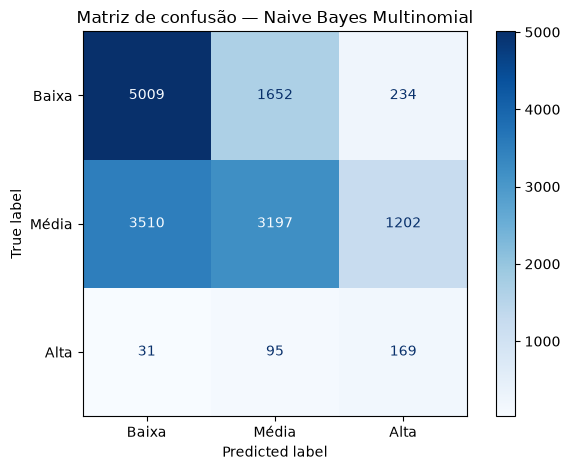

In [13]:
# Matriz de confusão do Naive Bayes Multinomial

import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay

classes_base = ["Baixa", "Media", "Alta"]
classes_exibicao = ["Baixa", "Média", "Alta"]

y_pred_nb_multinomial = cross_val_predict(
    modelo_naive_bayes,
    X,
    y,
    cv=cv_est,
    method="predict",
    n_jobs=-1,
)

ConfusionMatrixDisplay.from_predictions(
    y,
    y_pred_nb_multinomial,
    labels=classes_base,
    display_labels=classes_exibicao,
    cmap="Blues",
    values_format="d",
)
plt.title("Matriz de confusão — Naive Bayes Multinomial")
plt.tight_layout()
plt.show()